In [2]:
import matplotlib.pyplot as plt
import torch

from laya.scoring import (
    brier_score_reward,
    log_score,
    ranked_proba_score,
    spherical_score,
)

In [3]:
torch.manual_seed(42)

p = torch.tensor([[0.7, 0.2, 0.1]])

outcome = torch.tensor([0])

log_score(
    proba=p,
    outcomes=outcome,
)

tensor([-0.3567])

In [4]:
true_distribution = torch.tensor(
    [
        0.7,
        0.2,
        0.1,
    ]
)

n_samples = 100_000

outcomes = torch.multinomial(
    true_distribution,
    num_samples=n_samples,
    replacement=True,
)

torch.bincount(
    outcomes,
    minlength=3,
) / n_samples

tensor([0.6997, 0.1985, 0.1018])

In [5]:
honest = torch.tensor(
    [
        0.7,
        0.2,
        0.1,
    ]
)

overconfident = torch.tensor(
    [
        0.9,
        0.05,
        0.05,
    ]
)

honest_batch = honest.expand(n_samples, -1)
overconfident_batch = overconfident.expand(n_samples, -1)

honest_reward = log_score(honest_batch, outcomes).mean()
overconfident_reward = log_score(overconfident_batch, outcomes).mean()

print("honest:", honest_reward.item())
print("overconfident:", overconfident_reward.item())

honest: -0.8033975958824158
overconfident: -0.9732524752616882


In [6]:
def expected_log_score(report, truth):
    # sort of kl divergence
    return (truth * torch.log(report.clamp_min(1e-12))).sum()

In [7]:
expected_log_score(
    honest,
    true_distribution,
), expected_log_score(
    overconfident,
    true_distribution,
)

(tensor(-0.8018), tensor(-0.9725))

In [8]:
truth = torch.tensor(
    [
        0.7,
        0.3,
    ]
)

reported_p0 = torch.linspace(
    0.01,
    0.99,
    99,
)

reports = torch.stack(
    [
        reported_p0,
        1 - reported_p0,
    ],
    dim=1,
)

expected_rewards = (truth * torch.log(reports)).sum(dim=1)

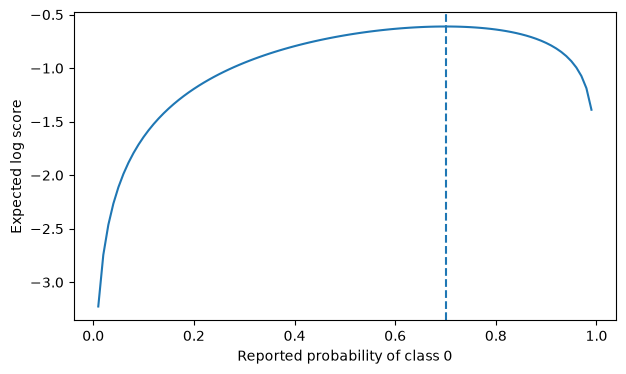

In [9]:
plt.figure(figsize=(7, 4))

plt.plot(
    reported_p0,
    expected_rewards,
)

plt.axvline(
    0.7,
    linestyle="--",
)

plt.xlabel("Reported probability of class 0")

plt.ylabel("Expected log score")

plt.show()

In [10]:
best_index = expected_rewards.argmax()

reported_p0[best_index]

tensor(0.7000)

brier


In [11]:
honest_reward = brier_score_reward(
    honest_batch,
    outcomes,
).mean()

overconfident_reward = brier_score_reward(
    overconfident_batch,
    outcomes,
).mean()

print(
    honest_reward.item(),
    overconfident_reward.item(),
)

-0.4606279730796814 -0.5254589915275574


spherical


In [12]:
honest_reward = spherical_score(
    honest_batch,
    outcomes,
).mean()

overconfident_reward = spherical_score(
    overconfident_batch,
    outcomes,
).mean()

print(
    honest_reward.item(),
    overconfident_reward.item(),
)

0.7344197034835815 0.7142108678817749


ranked probability


In [14]:
outcome = torch.tensor([2])

near_prediction = torch.tensor([[0.05, 0.35, 0.50, 0.10]])
far_prediction = torch.tensor([[0.50, 0.30, 0.15, 0.05]])
print(
    "near:",
    ranked_proba_score(
        near_prediction,
        outcome,
    ).item(),
)

print(
    "far:",
    ranked_proba_score(
        far_prediction,
        outcome,
    ).item(),
)

near: -0.17250001430511475
far: -0.8925000429153442


In [15]:
scoring_rules = {
    "log": log_score,
    "brier": brier_score_reward,
    "spherical": spherical_score,
}

for name, scoring_rule in scoring_rules.items():
    honest_reward = scoring_rule(
        honest_batch,
        outcomes,
    ).mean()

    dishonest_reward = scoring_rule(
        overconfident_batch,
        outcomes,
    ).mean()

    print(
        f"{name:10s}",
        f"honest={honest_reward.item():.4f}",
        f"overconfident={dishonest_reward.item():.4f}",
    )

log        honest=-0.8034 overconfident=-0.9733
brier      honest=-0.4606 overconfident=-0.5255
spherical  honest=0.7344 overconfident=0.7142
